# Trend on Binance perps, exploring the data

Trend following bets that a coin which has been rising keeps rising, and one which has been falling keeps falling. Before building that strategy, look at the data. Which coins exist, how clean they are, how they move, and whether past moves say anything about the next one.

The data is every crypto USDT perpetual Binance has ever listed, live or delisted, as daily bars from 2020 to August 2026, plus every funding payment. It is streamed from the Binance archive and cached locally.

## Loading and cleaning

Since late 2025 Binance also lists perps on stocks, ETFs, commodities and pre-IPO names, tagged TradFi, plus tokenised real assets such as gold. They are not crypto and do not move with it, so they are dropped first.

The archive keeps publishing bars for a coin after it stops trading. Those bars have zero volume and a frozen price. Counted as real, they make dead coins look alive and calm. Five rules clean this up.

1. A day counts only if something traded.
2. A daily return counts only if the day before also traded, so a return never spans a halt.
3. Each coin's first 30 trading days are skipped, while it finds its price.
4. A week counts only with at least 5 valid days.
5. A coin is tradeable in a week only if its median daily dollar volume over the last 30 days was at least \$1M, measured before the week starts.

Returns are log returns, the log of today's price over yesterday's. They add up across days, and a 1% move means the same on a coin at 60,000 as on one at 0.03.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qp_research import data, plot
from qp_research.data import universe
from qp_research.plot import BLUE, ORANGE, GREY

warnings.filterwarnings('ignore')
plot.style()

symbols = universe.perps(crypto_only=False)
bars, prints = data.daily_bars(symbols, '2020-01-01', '2026-09-01'), data.funding(symbols, '2020-01-01', '2026-09-01')
non_crypto = universe.non_crypto()
print(f'non-crypto perps dropped {bars[bars.symbol.isin(non_crypto)].symbol.nunique()}')
bars, prints = bars[~bars.symbol.isin(non_crypto)], prints[~prints.symbol.isin(non_crypto)]
close = bars.pivot(index='day', columns='symbol', values='close')
volume = bars.pivot(index='day', columns='symbol', values='volume')

traded = volume > 0
price = close.where(traded)
dollar_volume = (volume * close).where(traded)

daily = np.log(price).diff().where(traded & traded.shift(1, fill_value=False))
daily = daily.where(traded.cumsum().where(traded) > 30)

count = daily.notna().resample('W-SUN').sum()
weekly = daily.resample('W-SUN').sum(min_count=5).where(count >= 5)
liquidity = dollar_volume.rolling(30, min_periods=20).median().resample('W-SUN').last()
tradeable = liquidity.shift(1) >= 1e6
weekly_t = weekly.where(tradeable)

last_trade = traded[::-1].idxmax()
stopped = last_trade < close.index.max() - pd.Timedelta(days=14)
dead = (close.notna() & ~traded).sum()
print(f'coins {close.shape[1]}   stopped trading {int(stopped.sum())}   frozen days after trading stopped {int(dead.sum())}')
print('most frozen days', dead.sort_values(ascending=False).head(3).to_dict())
print(f'valid daily returns {int(daily.notna().sum().sum())}   tradeable coin-weeks {int(weekly_t.notna().sum().sum())}')
print()
bnx = bars[(bars.symbol == 'BNXUSDT') & bars.day.between('2023-02-19', '2023-02-23')]
print(bnx[['day', 'close', 'volume']].assign(day=bnx.day.dt.date).to_string(index=False))

non-crypto perps dropped 183


coins 681   stopped trading 157   frozen days after trading stopped 52773
most frozen days {'BTCSTUSDT': 1936, 'SCUSDT': 1536, 'FTTUSDT': 1386}
valid daily returns 548812   tradeable coin-weeks 75692

       day   close     volume
2023-02-19 119.930        0.0
2023-02-20 119.930        0.0
2023-02-21 119.930        0.0
2023-02-22   1.585 36745914.1
2023-02-23   1.355 64014099.9


183 non-crypto perps are dropped, leaving 681 coins. 157 stopped trading before the end, and the archive carries 52,773 frozen days for them. BTCST alone has 1,936.

The rules also handle halts. BNX sat frozen at 119.93 with no volume, then came back trading at 1.59 after a redenomination. Across the halt that reads as a 99% crash. Rule 2 drops it.

## How many coins there are to trade

Count the coins trading each week, the ones tradeable at \$1M a day, and the ones at \$10M a day. This is the real universe a strategy could hold at each point in time.

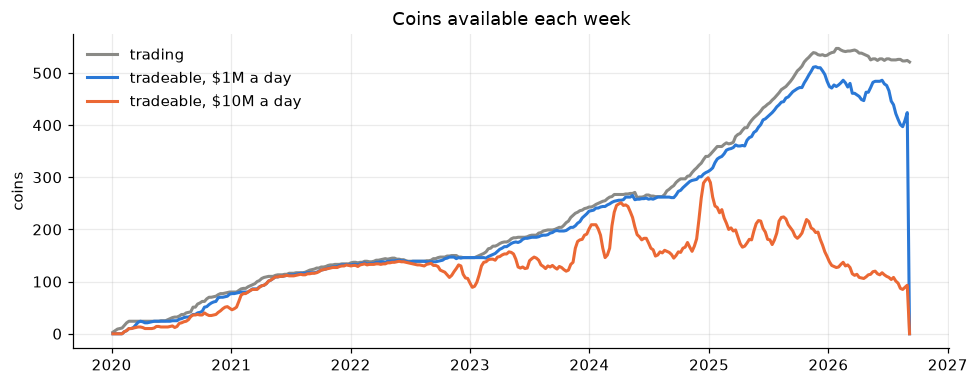

day      2020  2021  2022  2023  2024  2025  2026
trading    39   113   142   190   278   444   533
$1M        31   108   139   181   266   418   447
$10M       21   105   130   139   193   201   111


In [2]:
trading = traded.resample('W-SUN').max().sum(axis=1)
over_1m = weekly_t.notna().sum(axis=1)
over_10m = weekly.where(liquidity.shift(1) >= 1e7).notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(trading.index, trading, color=GREY, label='trading')
ax.plot(over_1m.index, over_1m, color=BLUE, label='tradeable, $1M a day')
ax.plot(over_10m.index, over_10m, color=ORANGE, label='tradeable, $10M a day')
ax.set_ylabel('coins'); ax.set_title('Coins available each week'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(pd.DataFrame({'trading': trading, '$1M': over_1m, '$10M': over_10m}).groupby(trading.index.year).mean().round(0).astype(int).T)

Coins tradeable at \$1M a day grew from 31 in 2020 to 447 in 2026, almost everything that trades. At \$10M a day the count peaked near 200 in 2024 and 2025 and fell to 111 in 2026. Most new listings are small. The deep, liquid universe is a few hundred coins at best.

## What returns look like

Look at the spread of weekly returns across tradeable coins against a normal bell curve, how volatile a typical coin is, and how much market volatility changes over time. Volatility here is the annualised standard deviation of daily returns.

coin-weeks 75692   mean -0.0142   median -0.0145   std 0.172   kurtosis 22.8
weeks beyond 3 std 0.0134   a normal curve gives 0.0027


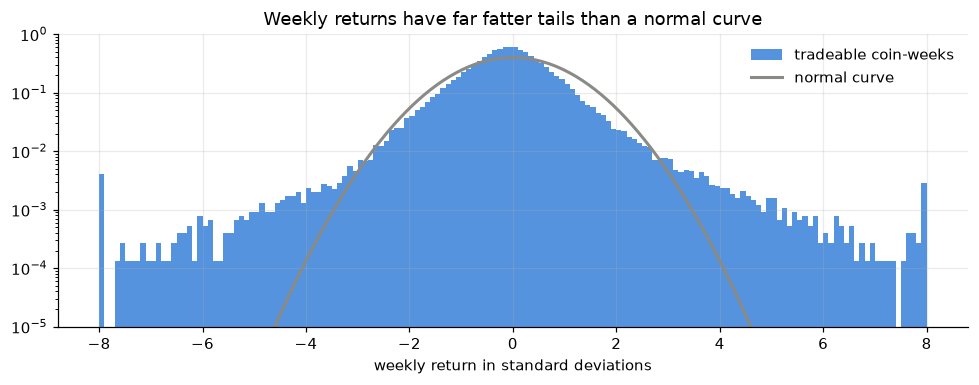

annualised volatility by coin {0.1: 0.93, 0.5: 1.2, 0.9: 2.07}
market volatility, 30-day, by year
day     2020  2021  2022  2023  2024  2025  2026
min     0.42  0.57  0.33  0.30  0.37  0.52  0.27
median  0.79  1.04  0.85  0.56  0.73  0.84  0.46
max     2.37  2.44  1.81  0.92  1.22  1.46  0.89


In [3]:
s = weekly_t.stack().dropna()
z = s / s.std()
print(f'coin-weeks {len(s)}   mean {s.mean():+.4f}   median {s.median():+.4f}   std {s.std():.3f}   kurtosis {s.kurt():.1f}')
print(f'weeks beyond 3 std {(z.abs() > 3).mean():.4f}   a normal curve gives 0.0027')

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(z.clip(-8, 8), bins=np.linspace(-8, 8, 161), density=True, color=BLUE, alpha=0.8, label='tradeable coin-weeks')
xs = np.linspace(-8, 8, 400)
ax.plot(xs, np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi), color=GREY, label='normal curve')
ax.set_yscale('log'); ax.set_ylim(1e-5, 1); ax.set_xlabel('weekly return in standard deviations')
ax.set_title('Weekly returns have far fatter tails than a normal curve'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

annual = daily.std() * np.sqrt(365)
print('annualised volatility by coin', annual.quantile([0.1, 0.5, 0.9]).round(2).to_dict())
tradeable_daily = tradeable.reindex(daily.index, method='bfill').fillna(False).astype(bool)
market_vol = daily.where(tradeable_daily).mean(axis=1).rolling(30).std() * np.sqrt(365)
print('market volatility, 30-day, by year')
print(market_vol.groupby(market_vol.index.year).agg(['min', 'median', 'max']).round(2).T)

A typical coin moves 120% a year. The calmest tenth move 93%, the wildest tenth 207%.

Tails are fat. 1.3% of coin-weeks land beyond 3 standard deviations, five times what a normal curve predicts. Kurtosis, a measure of how extreme the tails are, is 23 where a normal curve gives 0.

Market volatility swings from 27% to 244% a year and clusters. 2020 and 2021 peaked near 240%, 2023 never passed 92%, 2026 so far is the calmest with a median of 46%.

The average tradeable coin lost 1.4% a week. Mean and median agree, so it is not a few crashes pulling the average down.

## Putting coins on one scale

A 10% week is nothing for a meme coin and huge for BTC. Divide each coin's weekly return by its own volatility over the previous 12 weeks, so a move is measured in that coin's normal units. This is the main normalisation in finance. Compare the spread of weekly volatility across coins before and after.

In [4]:
vol_w = weekly.rolling(12, min_periods=8).std().shift(1)
scaled = weekly_t / vol_w
print('weekly std by coin, raw   ', weekly_t.std().quantile([0.1, 0.5, 0.9]).round(3).to_dict())
print('weekly std by coin, scaled', scaled.std().quantile([0.1, 0.5, 0.9]).round(2).to_dict())
print(f'kurtosis raw {weekly_t.stack().dropna().kurt():.1f}   scaled {scaled.stack().dropna().kurt():.1f}')

weekly std by coin, raw    {0.1: 0.115, 0.5: 0.16, 0.9: 0.265}
weekly std by coin, scaled {0.1: 0.99, 0.5: 1.15, 0.9: 1.49}
kurtosis raw 22.8   scaled 21.0


Raw weekly volatility runs from 12% to 27% across coins, more than twice apart. Scaled, coins land between 0.99 and 1.49, close to one each. They now sit on one scale and can be compared and pooled.

Scaling fixes size, not shape. Kurtosis only falls from 23 to 21, so the jumps are still there.

## Fitting the tails

A normal curve says a 4 standard deviation week almost never happens. Fit a Student t instead. It is a bell curve with one extra setting, the degrees of freedom. Low values mean heavy tails, and as it grows the t turns into the normal curve.

Fit it to the scaled weekly returns and to daily returns scaled by each coin's previous 60 days, then compare how often big moves really happen against what each curve predicts.

In [5]:
from scipy import stats

daily_vol = daily.rolling(60, min_periods=40).std().shift(1)
rows, lean = [], []
for name, x in [('weekly', scaled), ('daily', daily / daily_vol)]:
    x = x.stack().dropna()
    x = x[np.isfinite(x)]
    x = (x - x.mean()) / x.std()
    dof, loc, sc = stats.t.fit(x.sample(min(len(x), 200000), random_state=0))
    for k in [2, 3, 4, 6]:
        t_tail = stats.t.sf((k - loc) / sc, dof) + stats.t.cdf((-k - loc) / sc, dof)
        rows.append({'returns': name, 'dof': dof, 'beyond': f'{k} std', 'observed': (x.abs() > k).mean(),
                     'normal': 2 * stats.norm.sf(k), 'student_t': t_tail})
    lean.append({'returns': name, 'below -4 std': (x < -4).mean(), 'above +4 std': (x > 4).mean()})
print(pd.DataFrame(rows).set_index(['returns', 'beyond']).round(5))
print()
print(pd.DataFrame(lean).set_index('returns').round(5))

                    dof  observed   normal  student_t
returns beyond                                       
weekly  2 std   3.38126   0.04751  0.04550    0.04685
        3 std   3.38126   0.01370  0.00270    0.01484
        4 std   3.38126   0.00518  0.00006    0.00612
        6 std   3.38126   0.00135  0.00000    0.00166
daily   2 std   3.26480   0.04353  0.04550    0.04370
        3 std   3.26480   0.01353  0.00270    0.01410
        4 std   3.26480   0.00604  0.00006    0.00593
        6 std   3.26480   0.00199  0.00000    0.00167

         below -4 std  above +4 std
returns                            
weekly        0.00161       0.00357
daily         0.00283       0.00321


A Student t fits both, with about 3.4 degrees of freedom weekly and 3.3 daily. The normal curve understates 4 standard deviation moves about 100 times. The t lands close at every size. In the far tail it slightly overstates weekly moves and slightly understates daily ones.

Below 4 degrees of freedom, kurtosis has no stable value. That is why it reads 23 in one cut and something else in the next. The degrees of freedom is the number to quote.

The tails lean up. Weeks beyond +4 standard deviations happen more than twice as often as weeks beyond -4. Measured against their own volatility, coins spike up harder than they crash. For a short position that is squeeze risk. The t is symmetric, so a skewed version would be needed to capture it.

## How much coins move together

For each year, take the coins that were tradeable most of that year and measure three things. Average correlation between pairs of coins. The share of all movement explained by one common factor, which is the market. And the effective number of independent bets, a count of how many unrelated positions the whole set is really worth.

In [6]:
rows = []
for y in range(2020, 2027):
    blk = weekly_t.loc[str(y)]
    blk = blk.dropna(axis=1, thresh=int(0.8 * len(blk)))
    blk = blk.loc[:, blk.std() > 0]
    c = np.nan_to_num(blk.corr().values)
    n = c.shape[0]
    ev = np.linalg.eigvalsh(c)[::-1]
    rows.append({'year': y, 'coins': n, 'avg_corr': (c.sum() - n) / (n * (n - 1)),
                 'market_share': ev[0] / ev.sum(), 'independent_bets': ev.sum() ** 2 / (ev ** 2).sum()})
print(pd.DataFrame(rows).set_index('year').round(2))

      coins  avg_corr  market_share  independent_bets
year                                                 
2020     20      0.58          0.61              2.53
2021     86      0.60          0.62              2.54
2022    128      0.65          0.68              2.15
2023    153      0.57          0.60              2.76
2024    233      0.63          0.66              2.31
2025    339      0.58          0.62              2.56
2026    397      0.31          0.40              5.63


Coins move together. Average correlation sits between 0.57 and 0.65 every year to 2025, and the market explains 60 to 68% of all movement. Hundreds of coins are worth two or three independent bets. Adding coins adds very little diversification.

2026 is the exception so far. Correlation fell to 0.31, the market share to 40%, and the set is worth nearly six bets.

## The typical coin loses money

Compare three ways of holding the market. Every tradeable coin in equal amounts, every tradeable coin weighted by its dollar volume, and BTC alone. Then split the average weekly return by how long a coin has been trading, to see whether the losses are just fresh listings dumping.

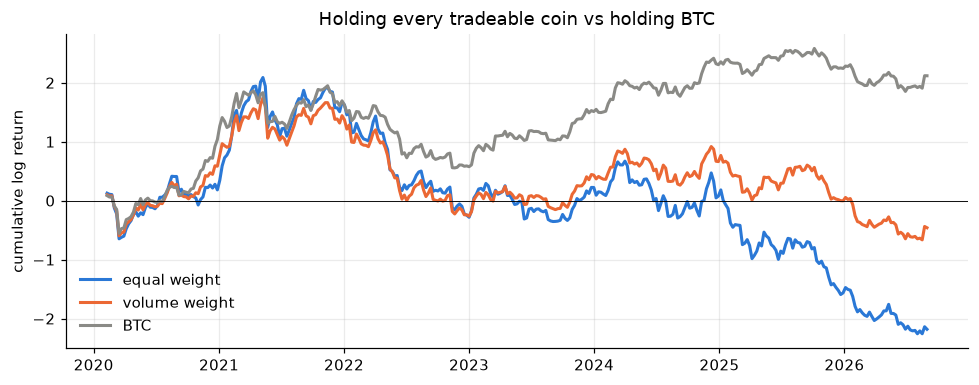

day            2020  2021  2022  2023  2024  2025  2026
equal weight   0.18  1.49 -1.92  0.47 -0.15 -1.64 -0.62
volume weight  0.58  0.86 -1.68  0.67  0.23 -0.66 -0.46
BTC            1.04  0.66 -1.10  0.92  0.79 -0.06 -0.12
whole span {'equal weight': -2.18, 'volume weight': -0.46, 'BTC': 2.12}



first 6 months  coin-weeks  14219   mean weekly -0.0149
6 to 12 months  coin-weeks  14674   mean weekly -0.0124
over a year     coin-weeks  46799   mean weekly -0.0146


In [7]:
w = liquidity.shift(1).where(tradeable)
paths = pd.DataFrame({'equal weight': weekly_t.mean(axis=1),
                      'volume weight': (weekly_t * w).sum(axis=1) / w.where(weekly_t.notna()).sum(axis=1),
                      'BTC': weekly['BTCUSDT']}).dropna()

fig, ax = plt.subplots(figsize=(9, 3.6))
for col, colour in zip(paths.columns, [BLUE, ORANGE, GREY]):
    ax.plot(paths.index, paths[col].cumsum(), color=colour, label=col)
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('cumulative log return')
ax.set_title('Holding every tradeable coin vs holding BTC'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(paths.groupby(paths.index.year).sum().round(2).T)
print('whole span', paths.sum().round(2).to_dict())
print()
age = traded.cumsum().resample('W-SUN').last().shift(1)
for lo, hi, name in [(0, 180, 'first 6 months'), (180, 365, '6 to 12 months'), (365, 10 ** 6, 'over a year')]:
    x = weekly_t.where((age > lo) & (age <= hi)).stack().dropna()
    print(f'{name:15} coin-weeks {len(x):6}   mean weekly {x.mean():+.4f}')

Holding every tradeable coin equally lost 2.18 in log terms over the span, about 89%. BTC gained 2.12, about eight times. Weighting by volume softens the loss to 0.46 but it is still a loss.

It is not just new listings. Coins in their first six months lose 1.49% a week, and coins over a year old lose 1.46%, about the same.

Two consequences. Shorting the average coin earned money over the span, so a trend book's short side starts with the wind behind it. And long-only is a weak yardstick for alts, since beating a strategy that lost 89% proves little.

## Does the past predict next week

This is the question trend following rests on. Take a coin's return over the last $L$ weeks, scaled by its volatility, and correlate it with its scaled return next week. Positive means moves continue, which is trend. Negative means moves snap back.

Three views, because coins move together.

- Coin alone. Each coin's own past against its own next week, pooled across coins.
- Whole market. The average tradeable coin's past against its next week.
- Coin vs market. Each coin's return minus the market's, so only what is special to that coin. Measured each week across coins, then averaged, so one big market week cannot count hundreds of times.

The t columns count standard errors from zero. Around 2 or more is the usual bar for believing a result is not luck.

    coin_alone  market  market_t  coin_vs_market  coin_vs_market_t
L                                                                 
1        0.005   0.076     1.385          -0.037            -3.451
2       -0.010   0.059     1.078          -0.042            -3.866
4        0.019   0.102     1.868          -0.020            -1.739
8        0.025   0.097     1.773          -0.002            -0.194
12       0.023   0.101     1.831           0.011             0.974

L = 4, by year
                 2020   2021   2022   2023   2024   2025   2026
market         -0.107  0.207 -0.086  0.024  0.049  0.032 -0.125
coin_vs_market  0.129 -0.028 -0.037 -0.066 -0.050 -0.002 -0.046
coin_alone      0.026  0.046 -0.034 -0.010  0.001  0.007 -0.054


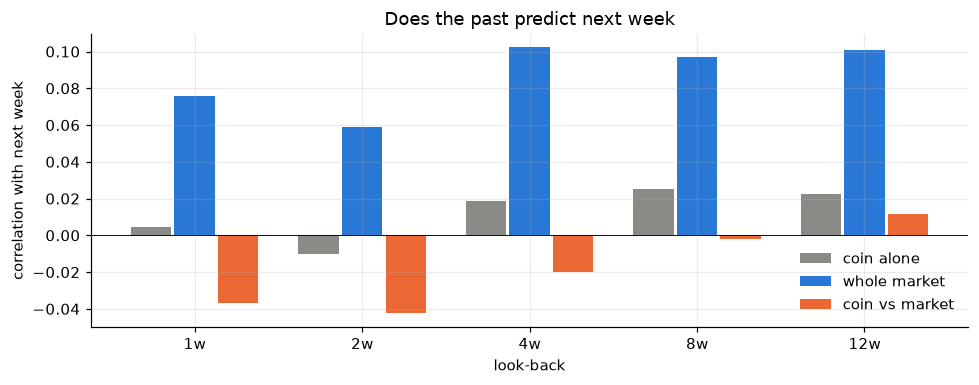

In [8]:
LOOKBACKS = [1, 2, 4, 8, 12]
nxt = scaled.shift(-1)
market = weekly_t.mean(axis=1)
market_vol_w = market.rolling(12, min_periods=8).std().shift(1)
relative = weekly_t.sub(market, axis=0)
relative_vol = relative.rolling(12, min_periods=8).std().shift(1)

def pooled(past, fut):
    j = pd.concat([past.stack(), fut.stack()], axis=1, keys=['p', 'n']).replace([np.inf, -np.inf], np.nan).dropna()
    return j[(j.p.abs() < 10) & (j.n.abs() < 10)]

def weekly_ic(past, fut):
    ic = past.corrwith(fut, axis=1, method='spearman')
    ok = past.notna() & fut.notna()
    ic = ic[ok.sum(axis=1) >= 20].dropna()
    return ic.mean(), ic.mean() / ic.std() * np.sqrt(len(ic))

rows, by_year = [], {}
for L in LOOKBACKS:
    own = pooled((weekly.rolling(L, min_periods=L).sum() / (vol_w * np.sqrt(L))).where(tradeable), nxt)
    pm = market.rolling(L).sum() / (market_vol_w * np.sqrt(L))
    nm = market.shift(-1) / market_vol_w
    ok = pm.notna() & nm.notna()
    rel_past = relative.rolling(L, min_periods=L).sum() / (relative_vol * np.sqrt(L))
    rel_next = (relative / relative_vol).shift(-1)
    rel_ic, rel_t = weekly_ic(rel_past, rel_next)
    m_corr = pm[ok].corr(nm[ok])
    rows.append({'L': L, 'coin_alone': own.p.corr(own.n), 'market': m_corr, 'market_t': m_corr * np.sqrt(ok.sum()),
                 'coin_vs_market': rel_ic, 'coin_vs_market_t': rel_t})
    if L == 4:
        yr = pm[ok].index.year
        by_year['market'] = pd.Series({y: pm[ok][yr == y].corr(nm[ok][yr == y]) for y in range(2020, 2027)})
        ic = rel_past.corrwith(rel_next, axis=1, method='spearman').dropna()
        by_year['coin_vs_market'] = ic.groupby(ic.index.year).mean()
        by_year['coin_alone'] = own.groupby(own.index.get_level_values(0).year).apply(lambda g: g.p.corr(g.n))
grid = pd.DataFrame(rows).set_index('L')
print(grid.round(3))
print()
print('L = 4, by year')
print(pd.DataFrame(by_year).round(3).T)

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(LOOKBACKS)); wd = 0.26
for i, (col, colour, lab) in enumerate([('coin_alone', GREY, 'coin alone'), ('market', BLUE, 'whole market'), ('coin_vs_market', ORANGE, 'coin vs market')]):
    ax.bar(x + (i - 1) * wd, grid[col], width=wd - 0.02, color=colour, label=lab)
ax.axhline(0, color='k', lw=0.6); ax.set_xticks(x); ax.set_xticklabels([f'{L}w' for L in LOOKBACKS])
ax.set_xlabel('look-back'); ax.set_ylabel('correlation with next week')
ax.set_title('Does the past predict next week'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The whole market trends, weakly. Its correlation with next week is +0.06 to +0.10 at every look-back, 1.1 to 1.9 standard errors from zero. Suggestive, not proven. It is carried by 2021, +0.21 at 4 weeks, and reverses in 2020, 2022 and 2026.

Coins against the market do the opposite. A coin that beat the market over the last 1 or 2 weeks tends to lag it next week, 3.5 to 3.9 standard errors from zero, and the sign holds in every year from 2021 at 4 weeks. By 8 weeks it has faded to nothing.

A coin on its own barely predicts itself, +0.025 at most. Its own trend is mostly the market's trend, partly cancelled by the snap-back against the market.

## Does it depend on liquidity

Split the coin-alone view at 4 weeks by daily dollar volume, to see whether any trend lives in the small coins or the large ones.

In [9]:
past4 = weekly.rolling(4, min_periods=4).sum() / (vol_w * 2)
for lo, hi, name in [(1e6, 1e7, '$1M to $10M'), (1e7, 5e7, '$10M to $50M'), (5e7, np.inf, 'over $50M')]:
    m = (liquidity.shift(1) >= lo) & (liquidity.shift(1) < hi)
    j = pooled(past4.where(m), nxt)
    print(f'{name:13} corr {j.p.corr(j.n):+.3f}   coin-weeks {len(j)}')

$1M to $10M   corr +0.003   coin-weeks 28116
$10M to $50M  corr +0.030   coin-weeks 24641
over $50M     corr +0.031   coin-weeks 16559


Coins trading \$1M to \$10M a day show nothing by this measure, +0.003. Above \$10M it is +0.030 in both buckets. A correlation weighs every coin-week equally, so it can miss a weaker effect that still shows up in money.

## Funding

Funding is the payment between longs and shorts on a perp every few hours. Positive means longs pay shorts. Sum it per week, average across tradeable coins by year, and check whether coins that rallied pay more.

In [10]:
fund = prints.pivot_table(index='t', columns='symbol', values='funding_rate', aggfunc='last')
fund_w = fund.resample('W-SUN').sum().reindex(weekly.index).where(tradeable)
fs = fund_w.stack().dropna()
print('mean weekly funding across tradeable coins, bps')
print((fs.groupby(fs.index.get_level_values(0).year).mean() * 1e4).round(1).to_frame('bps').T)
j = pd.concat([weekly.rolling(4, min_periods=4).sum().where(tradeable).stack(), fund_w.stack()], axis=1, keys=['ret', 'fund']).dropna()
print(f'trailing 4-week return vs that week funding, corr {j.ret.corr(j.fund):+.3f}   coin-weeks {len(j)}')

mean weekly funding across tradeable coins, bps
day  2020  2021  2022  2023  2024  2025  2026
bps  30.4  65.3  -9.3   9.1  23.4 -16.4 -23.7
trailing 4-week return vs that week funding, corr +0.043   coin-weeks 73664


Funding follows the cycle. Longs paid 30 to 65 bps a week in 2020 and 2021, and 23 in 2024. Shorts paid in 2022, 2025 and 2026. Coins that rallied pay slightly more, correlation +0.04. A trend book long a rising coin pays for the privilege, a book short a falling one mostly gets paid in bear years.

## What the data says

- Trend lives at the market level, not the coin level. It is weak, about 1.5 to 1.9 standard errors, and flips sign by year.
- The strongest pattern is the opposite of trend. Coins snap back against the market over 1 to 2 weeks, at 3.5 to 3.9 standard errors.
- The average coin decays about 1.4% a week at any age. Shorts earned, and long-only alts is a weak yardstick.
- Hundreds of coins are two or three independent bets. More coins add little.
- Volatility differs about twofold across coins and swings nearly tenfold over time. Scaling by it puts coins on one scale but does not remove the jumps.
- Returns follow a Student t with about 3.3 degrees of freedom, not a normal curve. 4 standard deviation weeks are about 100 times more common than a normal curve says, and the big ones lean up.
- Coins under \$10M a day show no trend by correlation.

Every number here is a correlation, not money. None of it is net of cost or funding.